In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ealtman2019/ibm-transactions-for-anti-money-laundering-aml")

print("Path to dataset files:", path)

/root/hackathon/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 7.61G/7.61G [03:55<00:00, 34.7MB/s]  

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/versions/8


In [11]:
df = pd.read_csv(r"/root/.cache/kagglehub/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/versions/8/HI-Small_Trans.csv")

In [12]:
df.head()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


In [81]:
df.info()

<class 'pandas.DataFrame'>
Index: 5078336 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   From Bank           object 
 1   Account             str    
 2   To Bank             object 
 3   Account.1           str    
 4   Amount Received     float64
 5   Receiving Currency  str    
 6   Amount Paid         float64
 7   Payment Currency    str    
 8   Payment Format      str    
 9   Is Laundering       object 
 10  Week                str    
dtypes: float64(2), object(3), str(6)
memory usage: 464.9+ MB


# Data Understanding 

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           str    
 1   From Bank           int64  
 2   Account             str    
 3   To Bank             int64  
 4   Account.1           str    
 5   Amount Received     float64
 6   Receiving Currency  str    
 7   Amount Paid         float64
 8   Payment Currency    str    
 9   Payment Format      str    
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), str(6)
memory usage: 426.2 MB


# Explotary Data Analysis

## Missing Value 

In [14]:
df.isna().sum()

Timestamp             0
From Bank             0
Account               0
To Bank               0
Account.1             0
Amount Received       0
Receiving Currency    0
Amount Paid           0
Payment Currency      0
Payment Format        0
Is Laundering         0
dtype: int64

## Duplicated

In [15]:
df.duplicated().sum()

np.int64(9)

In [16]:
df.drop_duplicates(inplace=True)

In [17]:
df.shape

(5078336, 11)

## Type Correction

In [18]:
df.dtypes

Timestamp                 str
From Bank               int64
Account                   str
To Bank                 int64
Account.1                 str
Amount Received       float64
Receiving Currency        str
Amount Paid           float64
Payment Currency          str
Payment Format            str
Is Laundering           int64
dtype: object

In [19]:
df['Timestamp']= pd.to_datetime(df['Timestamp'])
df['From Bank']= df['From Bank'].astype('object')
df['To Bank']= df['To Bank'].astype("object")
df['Is Laundering']= df["Is Laundering"].astype('object')

In [20]:
df.dtypes

Timestamp             datetime64[us]
From Bank                     object
Account                          str
To Bank                       object
Account.1                        str
Amount Received              float64
Receiving Currency               str
Amount Paid                  float64
Payment Currency                 str
Payment Format                   str
Is Laundering                 object
dtype: object

## Outlier

<Axes: >

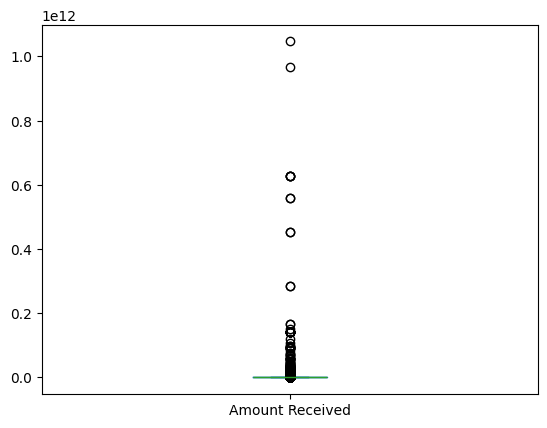

In [23]:
df['Amount Received'].plot(kind='box')

## Univariate Analysis

In [24]:
df.columns

Index(['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1',
       'Amount Received', 'Receiving Currency', 'Amount Paid',
       'Payment Currency', 'Payment Format', 'Is Laundering'],
      dtype='str')

In [25]:
df['Date']=df["Timestamp"].dt.date

In [26]:
df['Time']=df["Timestamp"].dt.time

In [27]:
df.head(3)

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Date,Time
0,2022-09-01 00:20:00,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0,2022-09-01,00:20:00
1,2022-09-01 00:20:00,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0,2022-09-01,00:20:00
2,2022-09-01 00:00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0,2022-09-01,00:00:00


<Axes: xlabel='Date'>

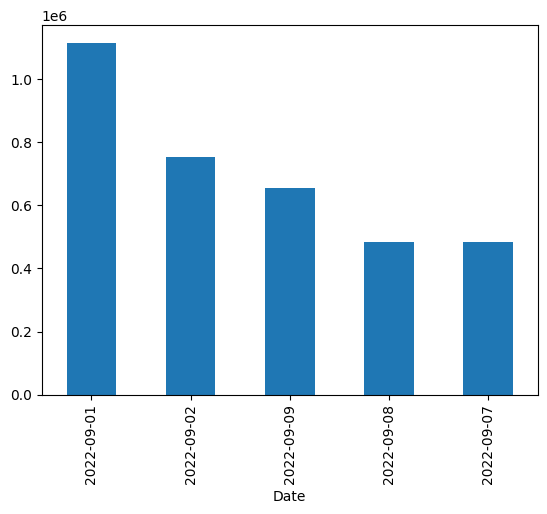

In [28]:
df['Date'].value_counts().head().plot(kind='bar')

<Axes: xlabel='Time'>

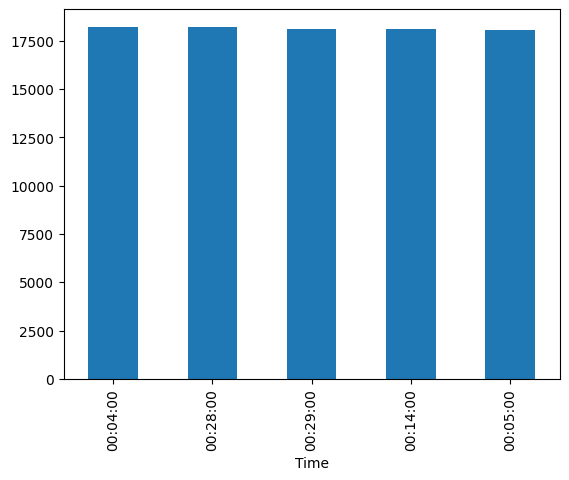

In [29]:
df['Time'].value_counts().head().plot(kind='bar')

In [30]:
# From Which Bank most of the transaction are Happened 
# From Which Account most of the transaction are Happened 
# To Which Bank most of the transaction are Happened 
# To Which Account most of the transaction are Happened 

In [31]:
df['Amount Received'].max()

np.float64(1046302363293.48)

In [32]:
df['Amount Received'].min()

np.float64(1e-06)

In [33]:
df['Amount Received'].mean()

np.float64(5988736.683497089)

In [34]:
df['Amount Paid'].mean()

np.float64(4509281.3592292)

In [35]:
df['Payment Currency'].unique()

<StringArray>
[        'US Dollar',           'Bitcoin',              'Euro',
 'Australian Dollar',              'Yuan',             'Rupee',
               'Yen',      'Mexican Peso',          'UK Pound',
             'Ruble',   'Canadian Dollar',       'Swiss Franc',
       'Brazil Real',       'Saudi Riyal',            'Shekel']
Length: 15, dtype: str

In [36]:
df['Payment Format'].unique()

<StringArray>
['Reinvestment', 'Cheque', 'Credit Card', 'ACH', 'Cash', 'Wire', 'Bitcoin']
Length: 7, dtype: str

In [37]:
df['Is Laundering'].value_counts()

Is Laundering
0    5073159
1       5177
Name: count, dtype: int64

In [38]:
df['Is Laundering'].value_counts()/df.shape[0]

Is Laundering
0    0.998981
1    0.001019
Name: count, dtype: float64

## Bi-Variate Analysis 

In [39]:
df[df['Is Laundering']==1]

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Date,Time
4742,2022-09-01 00:21:00,70,100428660,1124,800825340,389769.39,US Dollar,389769.39,US Dollar,Cheque,1,2022-09-01,00:21:00
40621,2022-09-01 00:03:00,70,100428660,11474,805B716C0,29024.33,US Dollar,29024.33,US Dollar,Credit Card,1,2022-09-01,00:03:00
69152,2022-09-01 00:01:00,70,100428660,15980,80B39E7B0,792.92,US Dollar,792.92,US Dollar,Credit Card,1,2022-09-01,00:01:00
85763,2022-09-01 00:03:00,70,100428660,113798,80DC756E0,13171425.53,US Dollar,13171425.53,US Dollar,Cheque,1,2022-09-01,00:03:00
90684,2022-09-01 00:23:00,70,100428660,32375,80E480620,14288.83,US Dollar,14288.83,US Dollar,Cash,1,2022-09-01,00:23:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5071168,2022-09-10 23:29:00,111433,8065C2380,21550,8065C69E0,7773.42,US Dollar,7773.42,US Dollar,ACH,1,2022-09-10,23:29:00
5073375,2022-09-10 23:07:00,9,80727F930,219557,8072A28C0,448920.65,Ruble,448920.65,Ruble,Cheque,1,2022-09-10,23:07:00
5074248,2022-09-12 03:34:00,222,812D127D0,50202,812D129C0,20085.71,Saudi Riyal,20085.71,Saudi Riyal,ACH,1,2022-09-12,03:34:00
5075056,2022-09-10 23:43:00,17327,8095F6C20,15695,8095F6C70,3314.36,US Dollar,3314.36,US Dollar,ACH,1,2022-09-10,23:43:00


In [40]:
df[df['Is Laundering']==1]['Date']

4742       2022-09-01
40621      2022-09-01
69152      2022-09-01
85763      2022-09-01
90684      2022-09-01
              ...    
5071168    2022-09-10
5073375    2022-09-10
5074248    2022-09-12
5075056    2022-09-10
5077204    2022-09-10
Name: Date, Length: 5177, dtype: object

In [41]:
df[df['Is Laundering']==1]['Date'].value_counts()

Date
2022-09-08    539
2022-09-06    531
2022-09-09    514
2022-09-07    497
2022-09-05    471
2022-09-10    442
2022-09-02    408
2022-09-04    407
2022-09-03    391
2022-09-01    322
2022-09-11    232
2022-09-12    170
2022-09-13    106
2022-09-14     70
2022-09-15     28
2022-09-16     26
2022-09-17     15
2022-09-18      8
Name: count, dtype: int64

<Axes: xlabel='Date'>

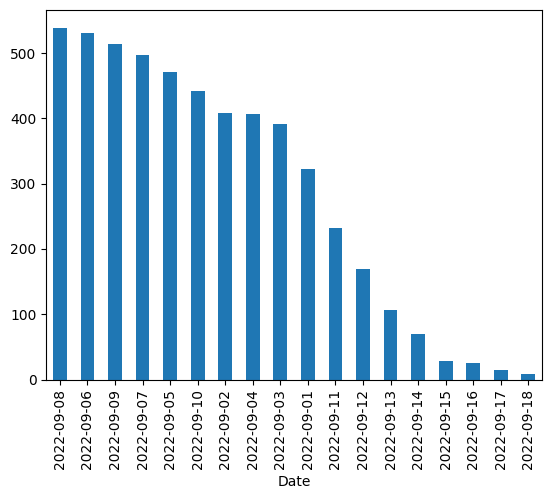

In [42]:
df[df['Is Laundering']==1]['Date'].value_counts().plot(kind='bar')

In [43]:
df[df['Is Laundering']==1]['Time'].value_counts()

Time
12:32:00    14
12:07:00    12
13:24:00    11
16:21:00    11
12:57:00    11
            ..
20:35:00     1
15:00:00     1
21:33:00     1
21:39:00     1
22:46:00     1
Name: count, Length: 1383, dtype: int64

<Axes: xlabel='Time'>

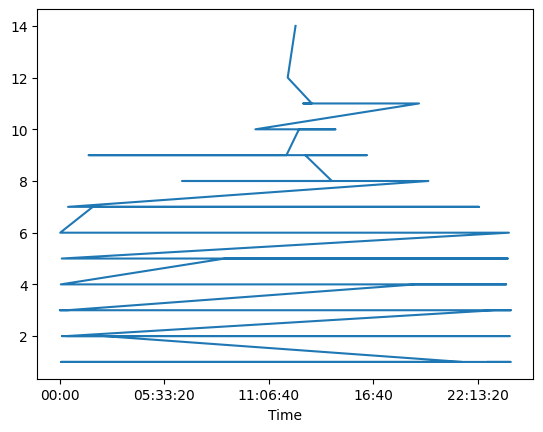

In [44]:
df[df['Is Laundering']==1]['Time'].value_counts().plot(kind='line')

In [45]:
df[df['Is Laundering']==1]['From Bank'].value_counts().head()

From Bank
70     633
12      76
20      67
119     59
10      51
Name: count, dtype: int64

<Axes: xlabel='From Bank'>

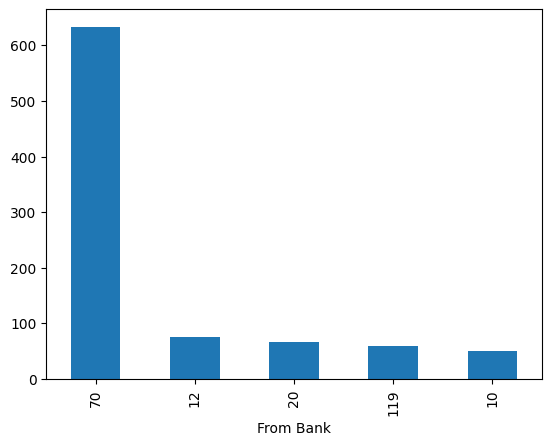

In [46]:
df[df['Is Laundering']==1]['From Bank'].value_counts().head().plot(kind='bar')

In [47]:
df[df['Payment Currency']=='US Dollar']

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Date,Time
0,2022-09-01 00:20:00,10,8000EBD30,10,8000EBD30,3697.340000,US Dollar,3697.34,US Dollar,Reinvestment,0,2022-09-01,00:20:00
1,2022-09-01 00:20:00,3208,8000F4580,1,8000F5340,0.010000,US Dollar,0.01,US Dollar,Cheque,0,2022-09-01,00:20:00
2,2022-09-01 00:00:00,3209,8000F4670,3209,8000F4670,14675.570000,US Dollar,14675.57,US Dollar,Reinvestment,0,2022-09-01,00:00:00
3,2022-09-01 00:02:00,12,8000F5030,12,8000F5030,2806.970000,US Dollar,2806.97,US Dollar,Reinvestment,0,2022-09-01,00:02:00
4,2022-09-01 00:06:00,10,8000F5200,10,8000F5200,36682.970000,US Dollar,36682.97,US Dollar,Reinvestment,0,2022-09-01,00:06:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078167,2022-09-10 23:30:00,23537,803949A90,23537,803949A90,26421.500000,Shekel,7823.96,US Dollar,ACH,0,2022-09-10,23:30:00
5078234,2022-09-10 23:59:00,16163,803638A90,16163,803638A90,47517.490000,Saudi Riyal,12667.62,US Dollar,ACH,0,2022-09-10,23:59:00
5078236,2022-09-10 23:55:00,16163,803638A90,16163,803638A90,11329.850000,Saudi Riyal,3020.41,US Dollar,ACH,0,2022-09-10,23:55:00
5078316,2022-09-10 23:44:00,215064,808F06E11,215064,808F06E10,0.000006,Bitcoin,0.07,US Dollar,ACH,0,2022-09-10,23:44:00


In [48]:
df[(df['Is Laundering'] == 1) & (df['Payment Currency'] == "US Dollar")]['Amount Paid'].sum()


np.float64(1208385176.9299998)

In [49]:
df[df['Is Laundering'] == 1]['Payment Format'].value_counts()


Payment Format
ACH            4483
Cheque          324
Credit Card     206
Cash            108
Bitcoin          56
Name: count, dtype: int64

<Axes: xlabel='Payment Format'>

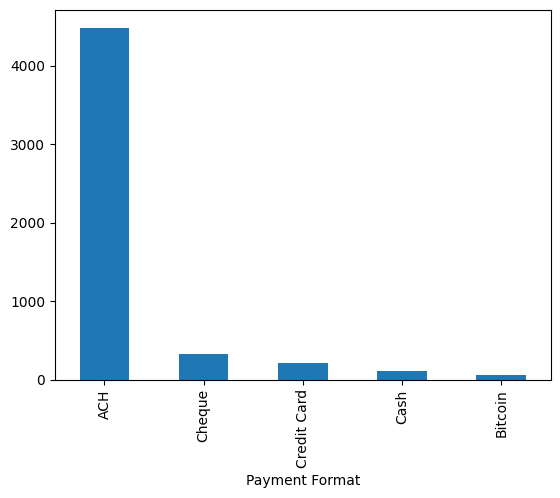

In [50]:
df[df['Is Laundering'] == 1]['Payment Format'].value_counts().plot(kind="bar")


## Relationship

In [51]:
df['Week']=df['Timestamp'].dt.day_name()

In [52]:
df.drop(["Timestamp",'Date'],axis =1,inplace = True)

In [53]:
df.head(2)

,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Time,Week
0,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0,00:20:00,Thursday
1,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0,00:20:00,Thursday


In [54]:
df.drop('Time',axis = 1,inplace = True)

In [55]:
contingency = pd.crosstab(df['Is Laundering'], df['Week'])


In [56]:
import scipy.stats as st
x,p,y,z = st.chi2_contingency(contingency)

if p < 0.05:
    print("There is a relationship")
else:
    print("There is no relation ship")

There is a relationship


In [57]:
contingency = pd.crosstab(df['Payment Format'],df['Is Laundering'])
x,p,y,z = st.chi2_contingency(contingency)

if p < 0.05:
    print("There is a relationship")
else:
    print("There is no relation ship")

There is a relationship


In [58]:
contingency = pd.crosstab(df['Payment Currency'],df['Is Laundering'])
x,p,y,z = st.chi2_contingency(contingency)

if p < 0.05:
    print("There is a relationship")
else:
    print("There is no relation ship")

There is a relationship


# Model Building

In [59]:
X = df.drop(['Is Laundering'],axis = 1)
y = df['Is Laundering']

In [60]:
cat = ['From Bank','Account','To Bank','Receiving Currency','Payment Currency','Payment Format','Week']

In [61]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [64]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

In [65]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3,random_state = 42)

In [66]:
ohe = Pipeline([('Encoder',OneHotEncoder(drop = 'first',handle_unknown='ignore'))])

In [67]:
transformer = ColumnTransformer([('One Hot Encoding',ohe,cat)])

In [68]:
model = Pipeline([("Transformer",transformer),
                 ("Estimator",XGBClassifier())])

In [69]:
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

/root/hackathon/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [70]:
from sklearn.metrics import classification_report

In [71]:
print(classification_report(y_test.astype('int'),y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1521879
           1       0.95      0.06      0.12      1622

    accuracy                           1.00   1523501
   macro avg       0.98      0.53      0.56   1523501
weighted avg       1.00      1.00      1.00   1523501



In [72]:
pip install imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [imblearn]
Note: you may need to restart the kernel to use updated packages.


In [73]:
from imblearn.under_sampling import RandomUnderSampler

In [74]:
rus = RandomUnderSampler()
X_s,y_s = rus.fit_resample(X,y.astype('int'))

In [76]:
X_train,X_test,y_train,y_test = train_test_split(X_s,y_s,test_size=0.3,random_state=42)
ohe = Pipeline([('Encoder',OneHotEncoder(drop = 'first',handle_unknown='ignore'))])
transformer = ColumnTransformer([('One Hot Encoding',ohe,cat)])
model = Pipeline([("Transformer",transformer),
                 ("Estimator",XGBClassifier())])
model.fit(X_train,y_train)
y_pred = model.predict(X_test).astype('object')
y_pred = model.predict(X_test)
print(classification_report(y_test.astype('int'),y_pred))

              precision    recall  f1-score   support

           0       0.94      0.81      0.87      1586
           1       0.83      0.95      0.89      1521

    accuracy                           0.88      3107
   macro avg       0.89      0.88      0.88      3107
weighted avg       0.89      0.88      0.88      3107



/root/hackathon/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/root/hackathon/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [ ]:
# Save model

In [77]:
import joblib
import os

save_dir = 'saved_model'
os.makedirs(save_dir, exist_ok=True)

joblib.dump(model, os.path.join(save_dir, 'aml_pipeline.joblib'))

joblib.dump(cat, os.path.join(save_dir, 'cat_columns.joblib'))

joblib.dump(list(X.columns), os.path.join(save_dir, 'feature_columns.joblib'))

print('モデルを保存しました:', os.listdir(save_dir))

モデルを保存しました: ['feature_columns.joblib', 'aml_pipeline.joblib', 'cat_columns.joblib']


In [78]:
loaded_model = joblib.load(os.path.join(save_dir, 'aml_pipeline.joblib'))
loaded_cat = joblib.load(os.path.join(save_dir, 'cat_columns.joblib'))
loaded_features = joblib.load(os.path.join(save_dir, 'feature_columns.joblib'))

print('モデルを読み込みました')
print('特徴量カラム:', loaded_features)
print('カテゴリカルカラム:', loaded_cat)

モデルを読み込みました
特徴量カラム: ['From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Week']
カテゴリカルカラム: ['From Bank', 'Account', 'To Bank', 'Receiving Currency', 'Payment Currency', 'Payment Format', 'Week']


In [79]:
# === 推論（テストデータの先頭5件で実行例） ===
sample_data = X_test.head(5)
print('入力データ:')
print(sample_data)
print()

# 予測
predictions = loaded_model.predict(sample_data)
probabilities = loaded_model.predict_proba(sample_data)

# 結果を表示
result_df = sample_data.copy()
result_df['予測結果'] = predictions
result_df['予測ラベル'] = ['マネーロンダリング' if p == 1 else '正常' for p in predictions]
result_df['不正確率'] = probabilities[:, 1]

print('推論結果:')
print(result_df[['予測結果', '予測ラベル', '不正確率']])

入力データ:
        From Bank    Account To Bank  Account.1  Amount Received  \
3239555        70  100428978   41148  80FCE8E50           365.89   
2879898        70  100428A08     222  811BE88E0         21270.90   
4736736     44565  81069B6E0   43460  81086B940           340.46   
778446      40312  80EEC44F0  138335  80F836090          4855.69   
2521566     10099  803C40120   10060  803DCA4B0         69382.45   

        Receiving Currency  Amount Paid Payment Currency Payment Format  \
3239555        Swiss Franc       365.89      Swiss Franc    Credit Card   
2879898        Saudi Riyal     21270.90      Saudi Riyal         Cheque   
4736736             Shekel       340.46           Shekel           Cash   
778446         Swiss Franc      4855.69      Swiss Franc         Cheque   
2521566                Yen     69382.45              Yen         Cheque   

             Week  
3239555   Tuesday  
2879898   Tuesday  
4736736    Friday  
778446   Thursday  
2521566    Monday  

推論結果:
      

/root/hackathon/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/root/hackathon/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [80]:
# === 新しいデータに対する推論関数 ===
def predict_laundering(input_df, model_path='saved_model/aml_pipeline.joblib'):
    """
    新しいトランザクションデータに対してマネーロンダリング判定を行う関数
    
    Parameters:
        input_df (pd.DataFrame): 特徴量を含むデータフレーム
        model_path (str): 保存されたモデルのパス
    
    Returns:
        pd.DataFrame: 予測結果を含むデータフレーム
    """
    loaded = joblib.load(model_path)
    
    preds = loaded.predict(input_df)
    probs = loaded.predict_proba(input_df)
    
    result = input_df.copy()
    result['prediction'] = preds
    result['label'] = ['Laundering' if p == 1 else 'Normal' for p in preds]
    result['laundering_probability'] = probs[:, 1]
    
    return result

# 使用例
result = predict_laundering(X_test.head(3))
print(result[['prediction', 'label', 'laundering_probability']])

         prediction       label  laundering_probability
3239555           1  Laundering                0.557538
2879898           0      Normal                0.478144
4736736           0      Normal                0.006748


/root/hackathon/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/root/hackathon/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
